In [8]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal
from langchain.messages import HumanMessage,AIMessage,SystemMessage
from langchain_openai import ChatOpenAI


In [3]:
import os
os.environ['OPENAI_API_KEY']="sk

In [5]:
llm=ChatOpenAI()

In [10]:
class tweetstate(TypedDict):
    topic:str
    tweet:str
    feedback:str
    evaluation:Literal['approved','not_approved']
    iteration:int
    max_iteration:int


In [29]:
def generate(state: tweetstate):
    messages = [
        SystemMessage(content="You are a helpful tweet generating influence"),
        HumanMessage(content=f"Please generate a tweet based on the topic -- {state['topic']}")
    ]
    response = llm.invoke(messages).content
    return {'tweet': response}

In [45]:
def evaluate(state: tweetstate):
    messages = [
        SystemMessage(content="You are a helpful tweet evaluating llm"),
        HumanMessage(content=f"Please evaluate the tweet based on the topic -- {state['topic']} already given -- {state['tweet']}. Do 2 things: one is generate feedback on what was needed, and the 2nd thing is give whether the tweet is approved or not approved. Return your response as a JSON object with keys 'evaluation' and 'feedback'.")
    ]
    
    response = llm.invoke(messages).content
    
    # If your LLM returns a proper JSON string
    import json
    result = json.loads(response)
    
    return {'evaluation': result['evaluation'], 'feedback': result['feedback']}

In [52]:
def optimiser(state:tweetstate):
    messages=[SystemMessage(content="You are a helpful AI Optimiser that optimises the tweet generated based on the topic."),
              HumanMessage(content=f"Please optimise the tweet based on the topic--{state['topic']} and the tweet provided --state['tweet']")]

            
    response=llm.invoke(messages).content
    iteration=state['iteration']+1
    return {'tweet':response,'iteration':iteration}


In [53]:
def condition(state:tweetstate):
    if state['evaluation']=='approved'or state['iteration']>=state['max_iteration']:
        return END
    return 'optimiser'

In [48]:
graph=StateGraph(tweetstate)
graph.add_node('generate',generate)
graph.add_node('evaluate',evaluate)
graph.add_node('optimiser',optimiser)

In [49]:
graph.add_edge(START,'generate')
graph.add_edge('generate','evaluate')
graph.add_conditional_edges('evaluate',condition)

graph.add_edge('optimiser','evaluate')


In [50]:
workflow=graph.compile()

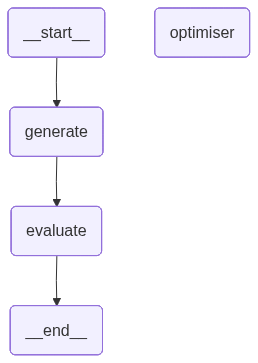

In [51]:
workflow

In [138]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [139]:
llm=ChatOpenAI()

C:\Users\ratha\AppData\Roaming\Python\Python312\site-packages\langgraph\graph\state.py:98: UserWarning: Invalid state_schema: <function SubState at 0x00000283FDD45120>. Expected a type or Annotated[type, reducer]. Please provide a valid schema to ensure correct updates.
 See: https://langchain-ai.github.io/langgraph/reference/graphs/#stategraph
  warnings.warn(


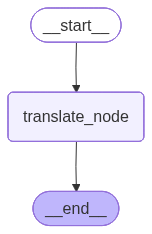

In [157]:
class ParentState(TypedDict):
    question:str
    english_answer:str
    hindi_answer:str

In [158]:
def generate_node(state:ParentState):
    prompt=f"Based on the given topic {state['question']} generate a summary in around 500 words"

    english_answer=llm.invoke(prompt).content

    return {'english_answer':english_answer}

In [160]:
def translate_node(state:ParentState):

    prompt=f'Based on the given response- {state['english_answer']},please give a hindi translation'

    result=llm.invoke(prompt).content

    return {'hindi_answer':result}
    

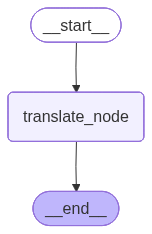

In [161]:
graph=StateGraph(ParentState)

graph.add_node('translate_node',translate_node)

graph.add_edge(START,'translate_node')
graph.add_edge('translate_node',END)

wf=graph.compile()

wf

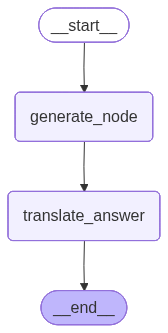

In [162]:
parentgraph=StateGraph(ParentState)

parentgraph.add_node('generate_node',generate_node)
parentgraph.add_node('translate_answer',wf)



parentgraph.add_edge(START,'generate_node')
parentgraph.add_edge('generate_node','translate_answer')
parentgraph.add_edge('translate_answer',END)

workflow=parentgraph.compile()

workflow

